In [16]:
# =====================================================
# IMPORTS
# =====================================================
import xarray as xr
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from shapely.geometry import Point
from shapely.prepared import prep
from cartopy.io.shapereader import Reader as ShapeReader
import dask
# =====================================================
# CONFIG
# =====================================================
xr.set_options(keep_attrs=True)

base_dir = "/home/lacrio/DATA/term_cal/res_new_day"
csv_days = "/home/lacrio/DATA/term_cal/range_date_evets.csv"
nc_pattern = "daymean_era5_t_uvw_{start}_{end}_thermo_budget.nc"

vars_plot = ["dT/dt", "adv_h", "adv_v", "Q"]
titles = ["dT/dt", "Horizontal Advection", "Vertical Advection", "Diabatic Heating"]


In [17]:
def load_event(row, i, rel_time_axis):

    start = pd.to_datetime(row["start_date"])
    end   = pd.to_datetime(row["end_date"])
    central = pd.to_datetime(row["event_date"]).normalize()

    path = os.path.join(
        base_dir,
        nc_pattern.format(
            start=start.strftime("%Y%m%d"),
            end=end.strftime("%Y%m%d")
        )
    )

    if not os.path.exists(path):
        print(f"⚠️ Missing: {path}")
        return None

    # --- Open dataset ---
    ds = xr.open_dataset(path, chunks="auto")

    time_coord = "valid_time" if "valid_time" in ds.coords else "time"

    # --- Force timestamps to 00:00 (KEY FIX) ---
    time_vals = pd.to_datetime(ds[time_coord].values).normalize().values

    # --- Relative time in DAYS ---
    rel_time = (
        (time_vals - np.datetime64(central)) 
        / np.timedelta64(1, "D")
    ).astype("int32")

    ds = ds.assign_coords({time_coord: rel_time})
    ds = ds.rename({time_coord: "time"})

    # --- Select window ---
    ds = ds.sel(time=slice(rel_time_axis.min(), rel_time_axis.max()))

    # --- Force same axis ---
    ds = ds.reindex(time=rel_time_axis)

    # --- Scaling ---
    ds = ds * 3600

    # --- Add event dimension ---
    ds = ds.expand_dims(event=[i])

    return ds

In [18]:
df = pd.read_csv(csv_days)#[0:20]
rel_time_axis = np.arange(-5, 6, 1, dtype=np.int32)
df

,start_date,event_date,end_date
0,1980-02-12,1980-02-17,1980-02-22
1,1980-12-18,1980-12-23,1980-12-28
2,1981-01-21,1981-01-26,1981-01-31
3,1981-12-04,1981-12-09,1981-12-14
4,1982-02-25,1982-03-02,1982-03-07
...,...,...,...
95,2021-11-04,2021-11-09,2021-11-14
96,2021-12-03,2021-12-08,2021-12-13
97,2021-12-14,2021-12-19,2021-12-24
98,2022-02-02,2022-02-07,2022-02-12


In [19]:
datasets = []

for i, row in df.iterrows():

    ds_evt = load_event(row, i, rel_time_axis)

    if ds_evt is None:
        continue

    datasets.append(ds_evt)

    if i % 10 == 0:
        print(f"➡️ Added {i+1} events")

➡️ Added 1 events
➡️ Added 11 events
➡️ Added 21 events
➡️ Added 31 events
➡️ Added 41 events
➡️ Added 51 events
➡️ Added 61 events
➡️ Added 71 events
➡️ Added 81 events
➡️ Added 91 events


In [20]:
ds_comp = xr.concat(datasets, dim="event")

In [51]:
# =====================================================
# MASK FUNCTION (UNCHANGED)
# =====================================================
# Patagonia Icefield (example bounds)
ds_PI = ds_comp.sel(
    longitude=slice(-75, -71),
    latitude=slice(-52, -45.8)
).mean(("latitude", "longitude", "event"))

# Antarctic Peninsula (example bounds)
ds_AP = ds_comp.sel(
    longitude=slice(-70, -60),
    latitude=slice(-70, -67)
).mean(("latitude", "longitude", "event"))

In [52]:
ds_AP

<xarray.Dataset> Size: 352B
Dimensions:  (time: 11)
Coordinates:
  * time     (time) int32 44B -5 -4 -3 -2 -1 0 1 2 3 4 5
Data variables:
    dT_dt    (time) float64 88B dask.array<chunksize=(11,), meta=np.ndarray>
    adv_h    (time) float64 88B dask.array<chunksize=(11,), meta=np.ndarray>
    adv_v    (time) float32 44B dask.array<chunksize=(11,), meta=np.ndarray>
    Q        (time) float64 88B dask.array<chunksize=(11,), meta=np.ndarray>
Attributes:
    description:  Thermodynamic budget at 700 hPa (NHESS method)
    history:      Computed from ERA5 single file

In [53]:
ds_12UTC = ds_comp.sel(time = 0).mean('event')

In [54]:
# -----------------------------------------------------------------------------
# Plot configuration
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

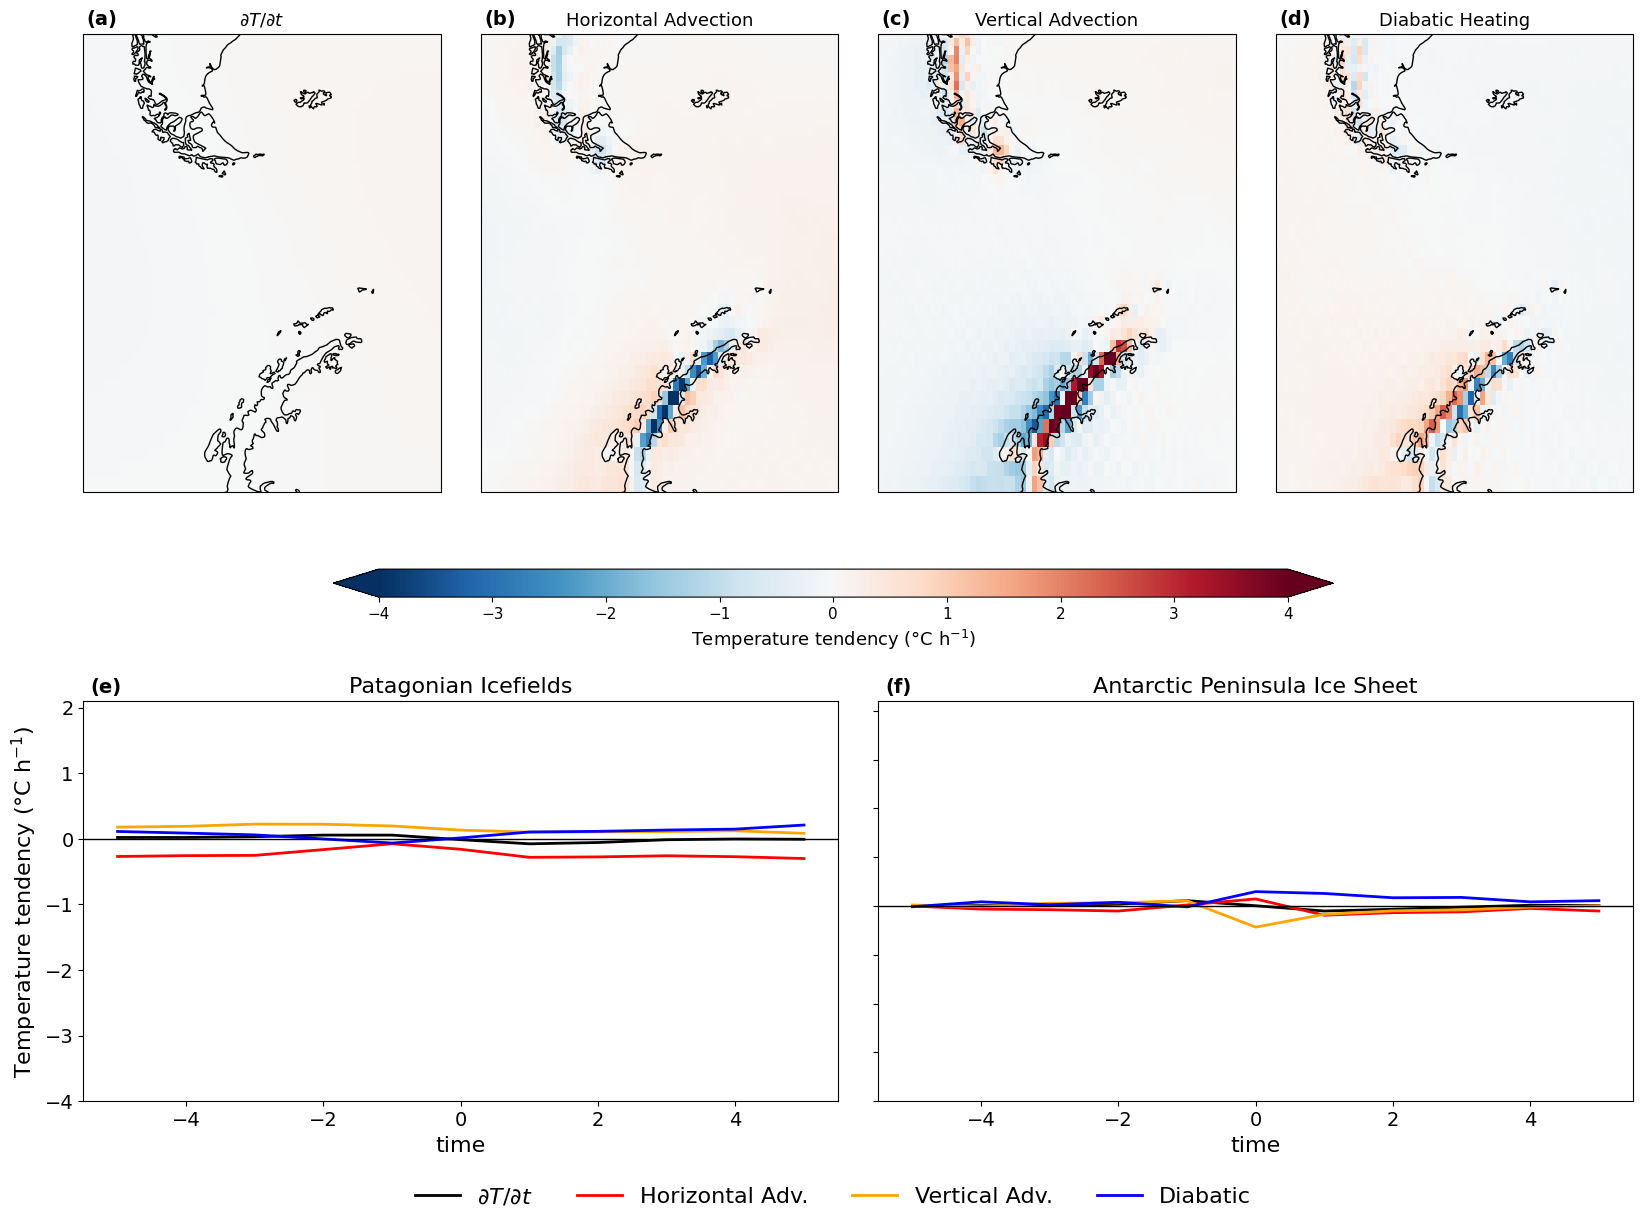

In [55]:
# =====================================================
# VARIABLES
# =====================================================
vars_plot = ["dT_dt", "adv_h", "adv_v", "Q"]

titles = [
    r"$\partial T / \partial t$",
    "Horizontal Advection",
    "Vertical Advection",
    "Diabatic Heating"
]

labels = {
    "dT_dt": r"$\partial T / \partial t$",
    "adv_h": "Horizontal Adv.",
    "adv_v": "Vertical Adv.",
    "Q": "Diabatic"
}

colors = {
    "dT_dt": "black",
    "adv_h": "red",
    "adv_v": "orange",
    "Q": "blue"
}

# =====================================================
# PLOTTING
# =====================================================
proj_map = ccrs.Mercator()
proj_data = ccrs.PlateCarree()

extent = [-80, -48, -68, -48]

fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    2, 8,
    height_ratios=[1.2, 1],
    hspace=0.45,
    wspace=0.25
)

# =====================================================
# MAPS (4 panels)
# =====================================================
for i, v in enumerate(vars_plot):

    ax = fig.add_subplot(gs[0, 2*i:2*i+2], projection=proj_map)

    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")

    im = ax.pcolormesh(
        ds_12UTC.longitude,
        ds_12UTC.latitude,
        ds_12UTC[v],
        cmap="RdBu_r",
        vmin=-4, vmax=4,
        shading="auto",
        transform=proj_data
    )

    ax.set_extent(extent)
    ax.set_title(titles[i], fontsize=13)

    ax.text(
        0.01, 1.02, f"({chr(97+i)})",
        transform=ax.transAxes,
        fontweight="bold",
        fontsize=14
    )

# =====================================================
# COLORBAR
# =====================================================
cax = fig.add_axes([0.25, 0.47, 0.5, 0.02])

cbar = fig.colorbar(im, cax=cax, orientation="horizontal", extend='both')
cbar.set_label("Temperature tendency (°C h$^{-1}$)", fontsize=13)
cbar.ax.tick_params(labelsize=11)

# =====================================================
# TIME SERIES
# =====================================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[1, 0:4])

for v in vars_plot:
    ds_PI[v].plot(
        ax=ax1,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax1.set_title("Patagonian Icefields", fontsize=16)
ax1.axhline(0, color="k", linewidth=1)

ax1.set_ylabel("Temperature tendency (°C h$^{-1}$)", fontsize=16)
ax1.set_ylim(-4.0, 2.1)
ax1.tick_params(labelsize=14)

ax1.text(0.01, 1.02, "(e)", transform=ax1.transAxes,
         fontsize=14, fontweight='bold')


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[1, 4:8])

for v in vars_plot:
    ds_AP[v].plot(
        ax=ax2,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax2.set_title("Antarctic Peninsula Ice Sheet", fontsize=16)
ax2.axhline(0, color="k", linewidth=1)

ax2.set_ylabel("")
ax2.set_ylim(-2.0, 2.1)
ax2.set_yticklabels([])
ax2.tick_params(labelsize=14)

ax2.text(0.01, 1.02, "(f)", transform=ax2.transAxes,
         fontsize=14, fontweight='bold')


# =====================================================
# 🔥 SHARED LEGEND (BEST PRACTICE)
# =====================================================
handles, legend_labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=16,
    bbox_to_anchor=(0.5, 0.02)
)

# =====================================================
# SAVE
# =====================================================
os.makedirs("./fig", exist_ok=True)
'''
fig.savefig(
    "./fig/temp_tendency_4vars.png",
    dpi=300,
    bbox_inches="tight"
)
'''
plt.show()